   0      1     2     3     4    5     6     7     8     9     10    11    12  \
0   1  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1   1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2   1  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3   1  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4   1  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

     13  
0  1065  
1  1050  
2  1185  
3  1480  
4   735  
   class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_phenols  Flavanoids  Nonflava

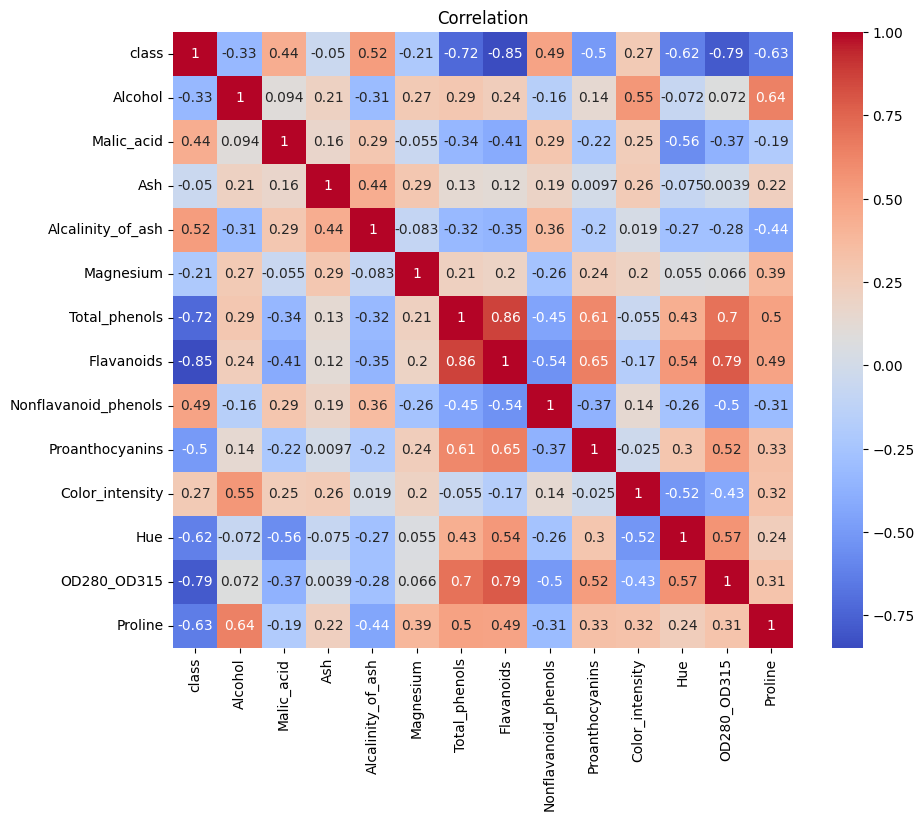

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load data
df = pd.read_csv('wine.data', header=None)
print(df.head())

# repair the data
columns = [
    'class',  
    'Alcohol',
    'Malic_acid',
    'Ash',
    'Alcalinity_of_ash',
    'Magnesium',
    'Total_phenols',
    'Flavanoids',
    'Nonflavanoid_phenols',
    'Proanthocyanins',
    'Color_intensity',
    'Hue',
    'OD280_OD315',
    'Proline'
]

df = pd.read_csv('wine.data', header=None, names=columns)

df.to_csv('wine.csv', index=False)
print(df.head())
print(df.info())
print(df.describe())

# Visualize the data
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

In [9]:
# Split Data
x = df.drop(['class'],axis=1)
y = df['class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, models in models.items():
    main_pipeline = Pipeline([
        ('Preprocessing', RobustScaler()),
        ('Models', models)
    ])
    main_pipeline.fit(x_train,y_train)
    predict = main_pipeline.predict(x_test)

    print(f'\n{name}')
    print('Classification Report\n', classification_report(y_test, predict))
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(main_pipeline, x, y, cv=skf, scoring='accuracy')
    print(f"Stratified CV: {scores.mean():.4f} ± {scores.std():.4f}")


Random Forest
Classification Report
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Stratified CV: 0.9889 ± 0.0222

Hist Gradient Boosting
Classification Report
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       0.93      1.00      0.97        14
           3       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36

Stratified CV: 0.9722 ± 0.0512

Support Vector Classifier
Classification Report
               precision    recall  f1-sco

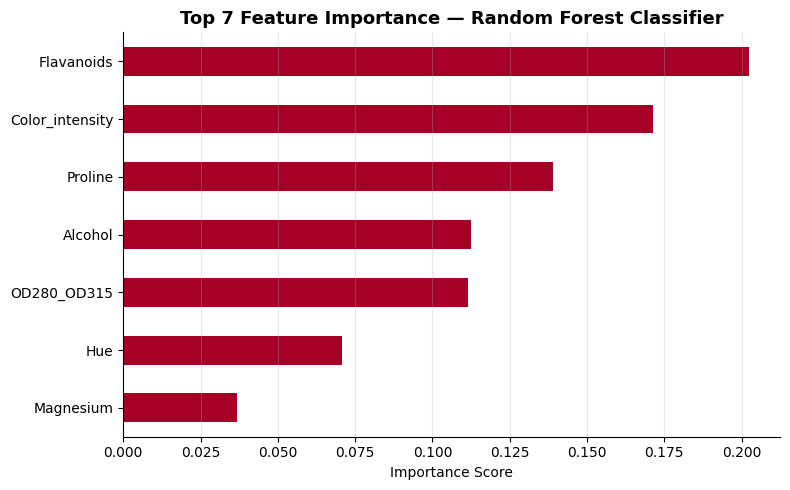

In [17]:
models = {
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}
best_model_name = 'Random Forest Classifier'
model = models[best_model_name]
main_pipeline = Pipeline([
    ('Preprocessing', RobustScaler()),
    ('Models', model)
])
main_pipeline.fit(x_train, y_train)
fitted_model = main_pipeline.named_steps['Models']

top5 = pd.Series(fitted_model.feature_importances_, index=x.columns).nlargest(7).sort_values()

top5.plot(kind='barh', figsize=(8, 5), colormap='RdYlGn')
plt.title(f'Top 7 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()